# 03 - Quantum-Aware Feature Selection (QAFS)

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Compares feature-selection strategies (spec section 8): classical mutual-information
ranking, classical PCA, and **Quantum-Aware Feature Selection (QAFS)** — a QUBO/QAOA-based
selector optimizing `J = a(1-PR_AUC) + b*FPR + c*ExpectedLoss + d*QubitCost + e*CircuitDepth + f*Latency`.
We also demonstrate the toy-scale swap-test "quantum PCA" routine, with an explicit honesty
note about why it does not replace classical PCA at real dataset scale (see
`src/quantum/quantum_pca.py`).

In [2]:
from src.data.loaders import load_synthetic
from src.data.preprocessing import clean_dataframe, fit_transform_split, infer_feature_types, random_split
from src.data.imbalance import stratified_subsample
from sklearn.feature_selection import mutual_info_classif
from src.quantum.quantum_pca import classical_pca, swap_test_quantum_pca
from src.quantum.qubo_feature_selection import qafs_select_features
from src.quantum.noise_models import get_primitives

ds = load_synthetic("ulb", n_samples=4000, random_state=42)
frame = clean_dataframe(ds.frame, ds.target)
numeric, categorical = infer_feature_types(frame, ds.target, ds.categorical_features)
splits = random_split(frame, ds.target, test_size=0.2, validation_size=0.15, random_state=42)
X_train, X_others, transformer, meta = fit_transform_split(
    splits["train"], {"val": splits["val"]}, ds.target, numeric, categorical
)
y_train = splits["train"][ds.target].values
feature_names = meta.output_feature_names
X_val, y_val = X_others["val"], splits["val"][ds.target].values
print(X_train.shape, len(feature_names))


(2600, 30) 30


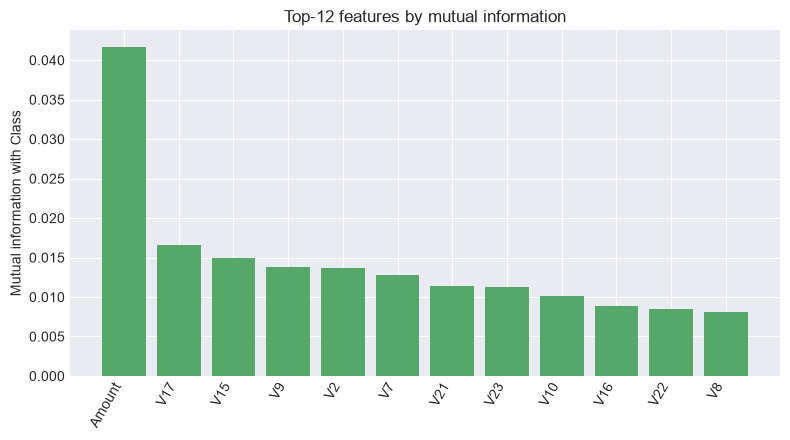

In [3]:
mi = mutual_info_classif(X_train, y_train, random_state=42)
order = np.argsort(-mi)[:12]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(order)), mi[order], color="#55A868")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([feature_names[i].replace("numeric__", "") for i in order], rotation=60, ha="right")
ax.set_ylabel("Mutual information with Class")
ax.set_title("Top-12 features by mutual information")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\03_mutual_information.png")
plt.show()


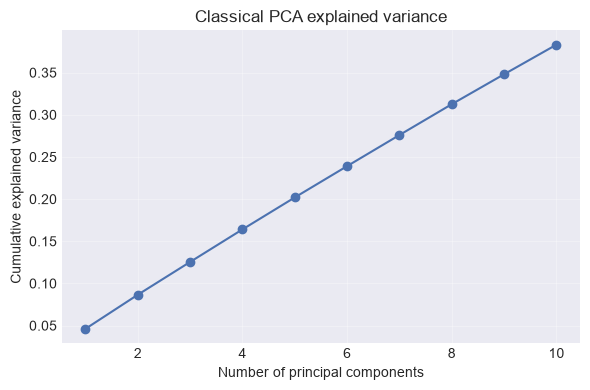

In [4]:
pca_result = classical_pca(X_train, n_components=10, random_state=42)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, 11), np.cumsum(pca_result.explained_variance_ratio), marker="o", color="#4C72B0")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Classical PCA explained variance")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\03_pca_variance.png")
plt.show()


In [5]:
weights = {"alpha": 1.0, "beta": 0.5, "gamma": 0.2, "delta": 0.3, "epsilon": 0.2, "zeta": 0.2}
fs_train_idx = stratified_subsample(X_train, y_train, 300, random_state=42)
fs_val_idx = stratified_subsample(X_val, y_val, 150, random_state=42)

candidates = qafs_select_features(
    X_train[fs_train_idx], y_train[fs_train_idx], X_val[fs_val_idx], y_val[fs_val_idx],
    feature_names, candidate_counts=[2, 4, 6], weights=weights, random_state=42,
)
qafs_df = pd.DataFrame([{"n_features": c.n_features, "pr_auc": c.pr_auc, "fpr": c.fpr,
                          "circuit_depth": c.circuit_depth, "J": c.J, "solver": c.solver_method,
                          "features": ", ".join(f.replace("numeric__", "") for f in c.selected_features)}
                         for c in candidates])
qafs_df


,n_features,pr_auc,fpr,circuit_depth,J,solver,features
0,2,0.509298,0.108108,10,1.821536,simulated_annealing,"V6, Amount"
1,4,0.530417,0.135135,19,1.976166,simulated_annealing,"V6, V19, V20, Amount"
2,6,0.508964,0.067568,25,1.663440,simulated_annealing,"V4, V6, V19, V25, V27, Amount"


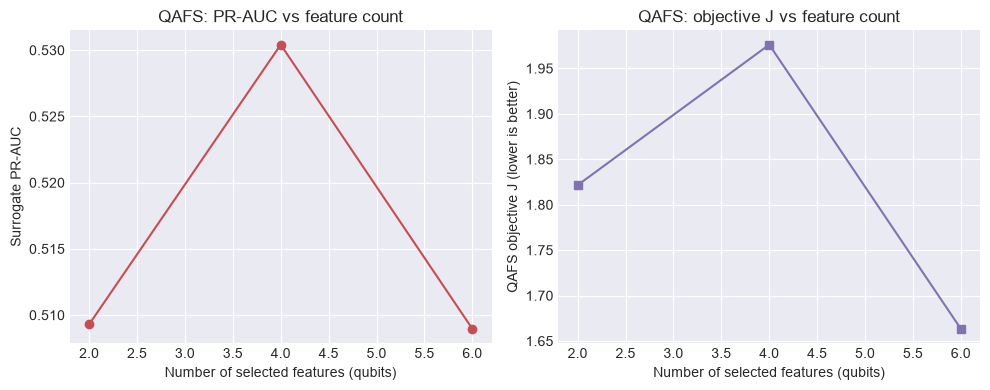

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(qafs_df["n_features"], qafs_df["pr_auc"], marker="o", color="#C44E52")
axes[0].set_xlabel("Number of selected features (qubits)"); axes[0].set_ylabel("Surrogate PR-AUC")
axes[0].set_title("QAFS: PR-AUC vs feature count")
axes[1].plot(qafs_df["n_features"], qafs_df["J"], marker="s", color="#8172B2")
axes[1].set_xlabel("Number of selected features (qubits)"); axes[1].set_ylabel("QAFS objective J (lower is better)")
axes[1].set_title("QAFS: objective J vs feature count")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\03_qafs_tradeoff.png")
plt.show()


In [7]:
# Toy-scale swap-test "quantum PCA" demo (honesty note: not a scalable
# substitute for classical PCA -- see src/quantum/quantum_pca.py docstring).
primitives = get_primitives(backend="simulator", shots=256, seed=42)
X_tiny = X_train[:6, :4]
qpca = swap_test_quantum_pca(X_tiny, n_components=2, primitives=primitives, max_samples=8, shots=256)
print("Toy quantum-PCA explained variance ratio:", qpca.explained_variance_ratio)
print(qpca.method)


Toy quantum-PCA explained variance ratio: [0.40248821 0.21622052]
swap_test_quantum_pca_toy_scale
